# Entrega Fourier 24/09/2026
### Brais Otero Lema

Fourier 1. Exercise 1: Piecewise function.

/tmp/ipykernel_8181/1202300867.py:37: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  a_n = lambda n : 2/period * quad(a_n_func, np.min(definition_interval), np.max(definition_interval), args=(n))[0]
/tmp/ipykernel_8181/1202300867.py:40: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the inter

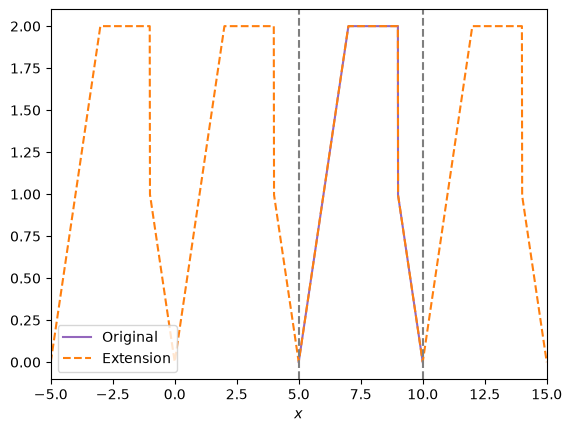

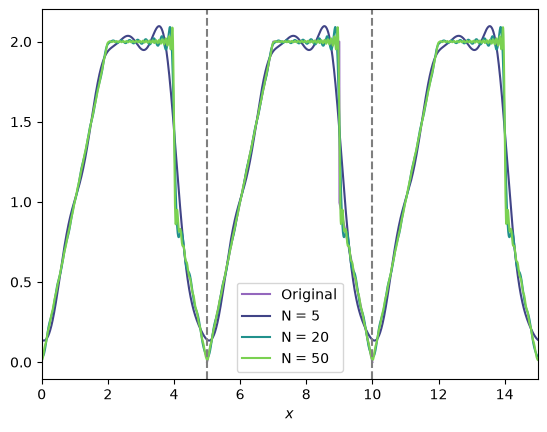

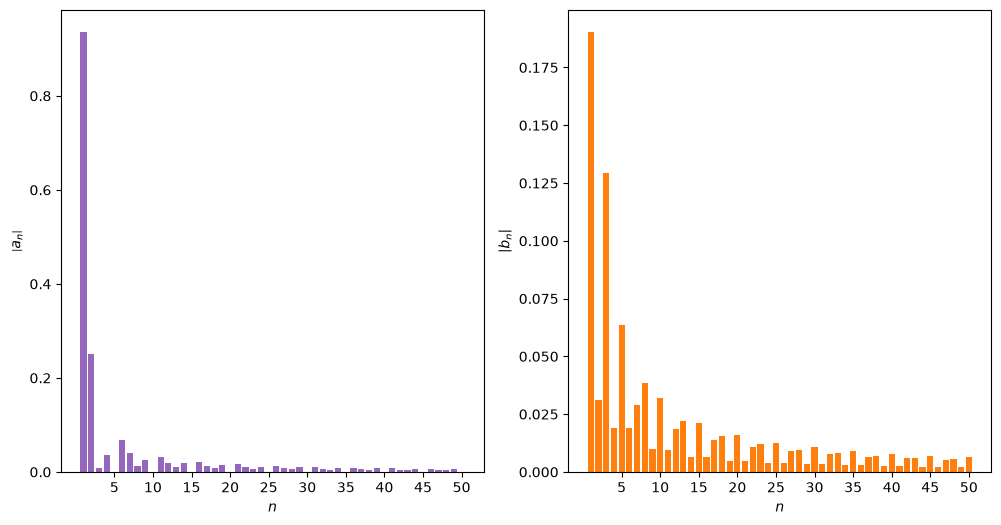

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
from scipy.integrate import quad
from cmasher import get_sub_cmap

sample_size = 2000
period = 5

piecewise_func = lambda x : (
    (x - 5) * np.heaviside(x - 5, 1) * np.heaviside(7 - x, 0)
    + 2 * np.heaviside(x - 7, 1) * np.heaviside(9 - x, 0)
    + (10 - x) * np.heaviside(x - 9, 1) * np.heaviside(10 - x, 0)
)

definition_interval = np.linspace(5, 10, sample_size)
extension_interval = np.linspace(-5, 15, sample_size)

interval_mapping = lambda x, original, target : ((x + np.min(target) - np.min(original)) % period) + np.min(target)

fig_ex, ax_ex = subplots()

ax_ex.plot(definition_interval, piecewise_func(definition_interval), ls="solid", color="tab:purple", label="Original")
ax_ex.plot(extension_interval, piecewise_func(interval_mapping(extension_interval, extension_interval, definition_interval)), ls="dashed", color="tab:orange", label="Extension")

ax_ex.axvline(np.min(definition_interval), ls="dashed", color="tab:gray")
ax_ex.axvline(np.max(definition_interval), ls="dashed", color="tab:gray")

ax_ex.set_xlim(left=np.min(extension_interval), right=np.max(extension_interval))

ax_ex.set_xlabel(r"$x$")

ax_ex.legend(loc="best")

a_0 = 2/period * quad(piecewise_func, np.min(definition_interval), np.max(definition_interval))[0]

a_n_func = lambda x, n : piecewise_func(x) * np.cos(n*2*np.pi/period * x)
a_n = lambda n : 2/period * quad(a_n_func, np.min(definition_interval), np.max(definition_interval), args=(n))[0]

b_n_func = lambda x, n : piecewise_func(x) * np.sin(n*2*np.pi/period * x)
b_n = lambda n : 2/period * quad(b_n_func, np.min(definition_interval), np.max(definition_interval), args=(n))[0]

sum_term = lambda x, n : a_n(n) * np.cos(n*2*np.pi/period * x) + b_n(n) * np.sin(n*2*np.pi/period * x)
def partial_sum(x, N):
    s = a_0/2
    for n in range(1, N+1):
        s += sum_term(x, n)
    return s

series_interval = np.linspace(0, 15, sample_size)
Ns = (5, 20, 50)
colors = [c for c in get_sub_cmap("viridis", .2, .8, N=len(Ns)).colors]

fig_sum, ax_sum = subplots()

ax_sum.plot(definition_interval, piecewise_func(definition_interval), ls="solid", color="tab:purple", label="Original")
for N, color in zip(Ns, colors):
    ax_sum.plot(series_interval, partial_sum(series_interval, N), ls="solid", color=color, label=f"N = {N}")

ax_sum.axvline(np.min(definition_interval), ls="dashed", color="tab:gray")
ax_sum.axvline(np.max(definition_interval), ls="dashed", color="tab:gray")

ax_sum.set_xlim(left=np.min(series_interval), right=np.max(series_interval))

ax_sum.set_xlabel(r"$x$")

ax_sum.legend(loc="best")

fig_d, axs_d = subplots(1, 2, figsize=(12, 6))

ns = np.arange(1, 51)
a_ns = [a_n(n) for n in ns]
b_ns = [b_n(n) for n in ns]

axs_d[0].bar(ns, np.abs(a_ns), color="tab:purple")
axs_d[1].bar(ns, np.abs(b_ns), color="tab:orange")

axs_d[0].set_ylabel(r"$\left\vert a_n \right\vert$")
axs_d[1].set_ylabel(r"$\left\vert b_n \right\vert$")

for ax in axs_d:
    ax.set_xlabel(r"$n$")

    ax.set_xticks(ns[4::5])


Fourier 1. Exercise 2: Sawtooth wave.

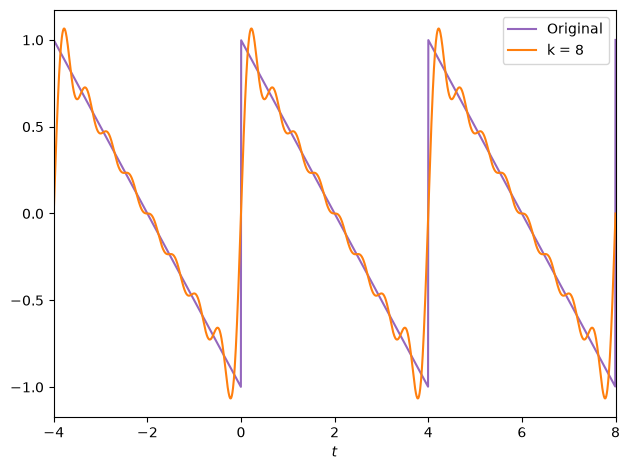

In [2]:
import numpy as np
from matplotlib.pyplot import subplots
from scipy.integrate import quad

sample_size = 2000
period = 4
k = 8

slope = lambda t : 1 - .5*t

definition_interval = np.linspace(0, 4, sample_size)
extension_interval = np.linspace(-4, 8, sample_size)

interval_mapping = lambda t, original, target : ((t + np.min(target) - np.min(original)) % period) + np.min(target)

a_0 = 2/period * quad(slope, np.min(definition_interval), np.max(definition_interval))[0]

a_n_func = lambda x, n : slope(x) * np.cos(n*2*np.pi/period * x)
a_n = lambda n : 2/period * quad(a_n_func, np.min(definition_interval), np.max(definition_interval), args=(n))[0]

b_n_func = lambda x, n : slope(x) * np.sin(n*2*np.pi/period * x)
b_n = lambda n : 2/period * quad(b_n_func, np.min(definition_interval), np.max(definition_interval), args=(n))[0]

sum_term = lambda x, n : a_n(n) * np.cos(n*2*np.pi/period * x) + b_n(n) * np.sin(n*2*np.pi/period * x)
def partial_sum(x, N):
    s = a_0/2
    for n in range(1, N+1):
        s += sum_term(x, n)
    return s

fig, ax = subplots()

ax.plot(extension_interval, slope(interval_mapping(extension_interval, extension_interval, definition_interval)), ls="solid", color="tab:purple", label="Original")
ax.plot(extension_interval, partial_sum(extension_interval, k), ls="solid", color="tab:orange", label=f"k = {k}")

ax.set_xlim(left=np.min(extension_interval), right=np.max(extension_interval))

ax.set_xlabel(r"$t$")

ax.legend(loc="best")

fig.tight_layout()

Fourier 1. Exercise 3: Non-periodic function.

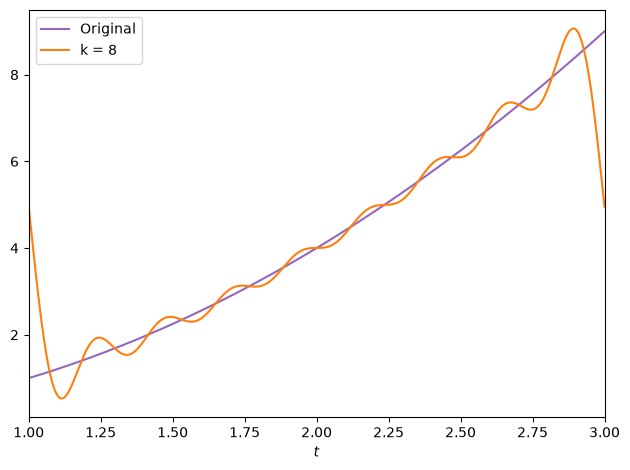

In [3]:
import numpy as np
from matplotlib.pyplot import subplots
from scipy.integrate import quad

sample_size = 2000
period = 2
k = 8

non_periodic = lambda t : t**2

tlin = np.linspace(1, 3, sample_size)

a_0 = 2/period * quad(non_periodic, np.min(tlin), np.max(tlin))[0]

a_n_func = lambda x, n : non_periodic(x) * np.cos(n*2*np.pi/period * x)
a_n = lambda n : 2/period * quad(a_n_func, np.min(tlin), np.max(tlin), args=(n))[0]

b_n_func = lambda x, n : non_periodic(x) * np.sin(n*2*np.pi/period * x)
b_n = lambda n : 2/period * quad(b_n_func, np.min(tlin), np.max(tlin), args=(n))[0]

sum_term = lambda x, n : a_n(n) * np.cos(n*2*np.pi/period * x) + b_n(n) * np.sin(n*2*np.pi/period * x)
def partial_sum(x, N):
    s = a_0/2
    for n in range(1, N+1):
        s += sum_term(x, n)
    return s

fig, ax = subplots()

ax.plot(tlin, non_periodic(tlin), ls="solid", color="tab:purple", label="Original")
ax.plot(tlin, partial_sum(tlin, k), ls="solid", color="tab:orange", label=f"k = {k}")

ax.set_xlim(left=np.min(tlin), right=np.max(tlin))

ax.set_xlabel(r"$t$")

ax.legend(loc="best")

fig.tight_layout()

Fourier 2. Exercise 1: Power spectrum.

Signal frequencies: f_1 = 30 Hz and f_2 = 80 Hz.
After Fourier transform:
Frequency peak at 30.0 Hz with power 0.250.
Frequency peak at 80.0 Hz with power 0.063.
Frequency peak at 920.0 Hz with power 0.063.
Frequency peak at 970.0 Hz with power 0.250.


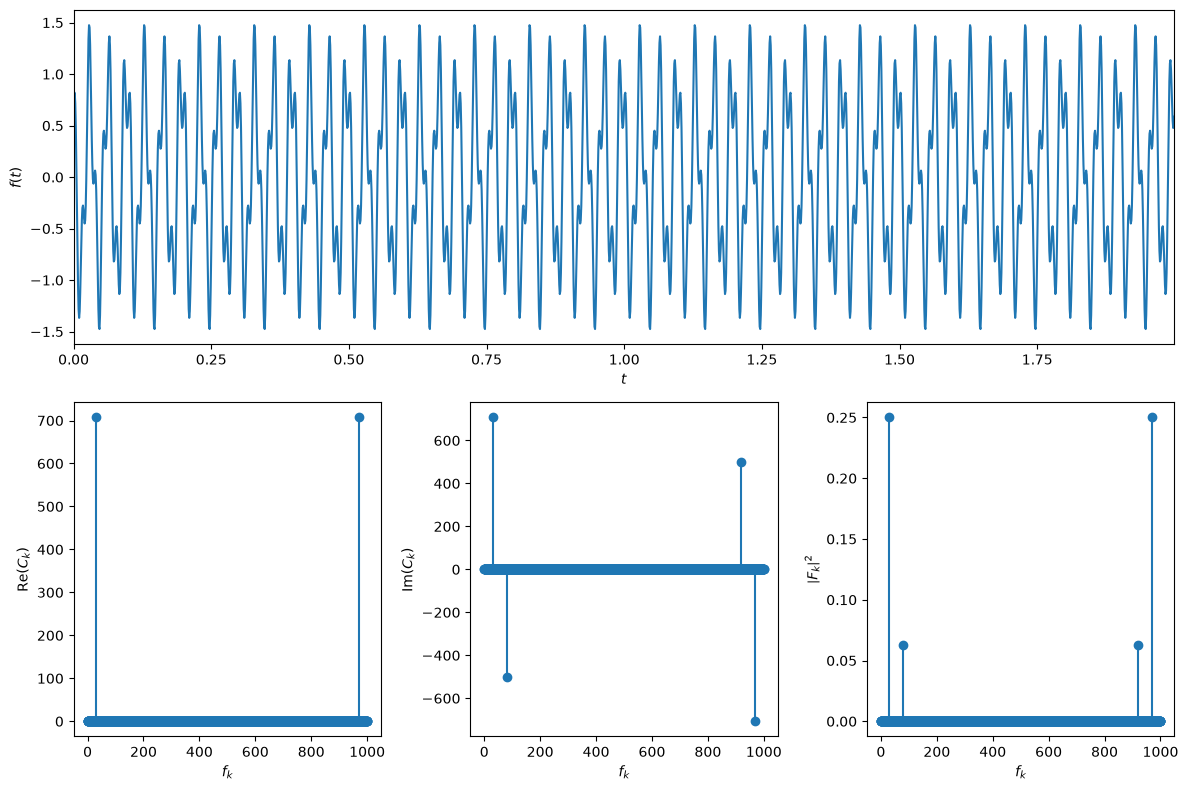

In [4]:
import numpy as np
from numpy.fft import fft
from matplotlib.pyplot import subplot_mosaic

f_1, f_2 = 30, 80
phi = np.pi/4

signal = lambda t : np.cos(2*np.pi*f_1*t + phi) + .5*np.sin(2*np.pi*f_2*t)

sampling_start, sampling_end = 0, 2
sample_number = 2000
sampling_interval = np.linspace(sampling_start, sampling_end, sample_number, endpoint=False)
frequencies = np.arange(len(sampling_interval)) / (sampling_end - sampling_start)

coefficients = fft(signal(sampling_interval))

fig, axs = subplot_mosaic([["signal", "signal", "signal"], ["real", "imag", "power"]], figsize=(12,8))

axs["signal"].plot(sampling_interval, signal(sampling_interval), ls="solid")

axs["signal"].set_xlim(left=np.min(sampling_interval), right=np.max(sampling_interval))

axs["signal"].set_xlabel(r"$t$")
axs["signal"].set_ylabel(r"$f(t)$")

axs["real"].stem(frequencies, np.real(coefficients), basefmt=" ")

axs["real"].set_ylabel(r"Re$(C_k)$")

axs["imag"].stem(frequencies, np.imag(coefficients), basefmt=" ")

axs["imag"].set_ylabel(r"Im$(C_k)$")

power_spectrum = np.abs(coefficients/len(sampling_interval))**2
axs["power"].stem(frequencies, power_spectrum, basefmt=" ")

axs["power"].set_ylabel(r"$\left\vert F_k \right\vert^2$")

for ax in (axs["real"], axs["imag"], axs["power"]):
    ax.set_xlabel(r"$f_k$")

fig.tight_layout()

rounded_spectrum = np.round(power_spectrum, 2)
peaks_freqs = np.nonzero(rounded_spectrum)
peaks_vals = power_spectrum[peaks_freqs]

print(f"Signal frequencies: f_1 = {f_1} Hz and f_2 = {f_2} Hz.")
print("After Fourier transform:")
for peak_freq, peak_val in zip(peaks_freqs[0], peaks_vals):
    print(f"Frequency peak at {frequencies[peak_freq]} Hz with power {peak_val:.3f}.")


Fourier 2. Exercise 2: Fine sampling.

Signal frequency: f = 250 Hz.
After Fourier transform:
Frequency peak at 250.0 Hz with power 0.250.
Frequency peak at 1750.0 Hz with power 0.250.


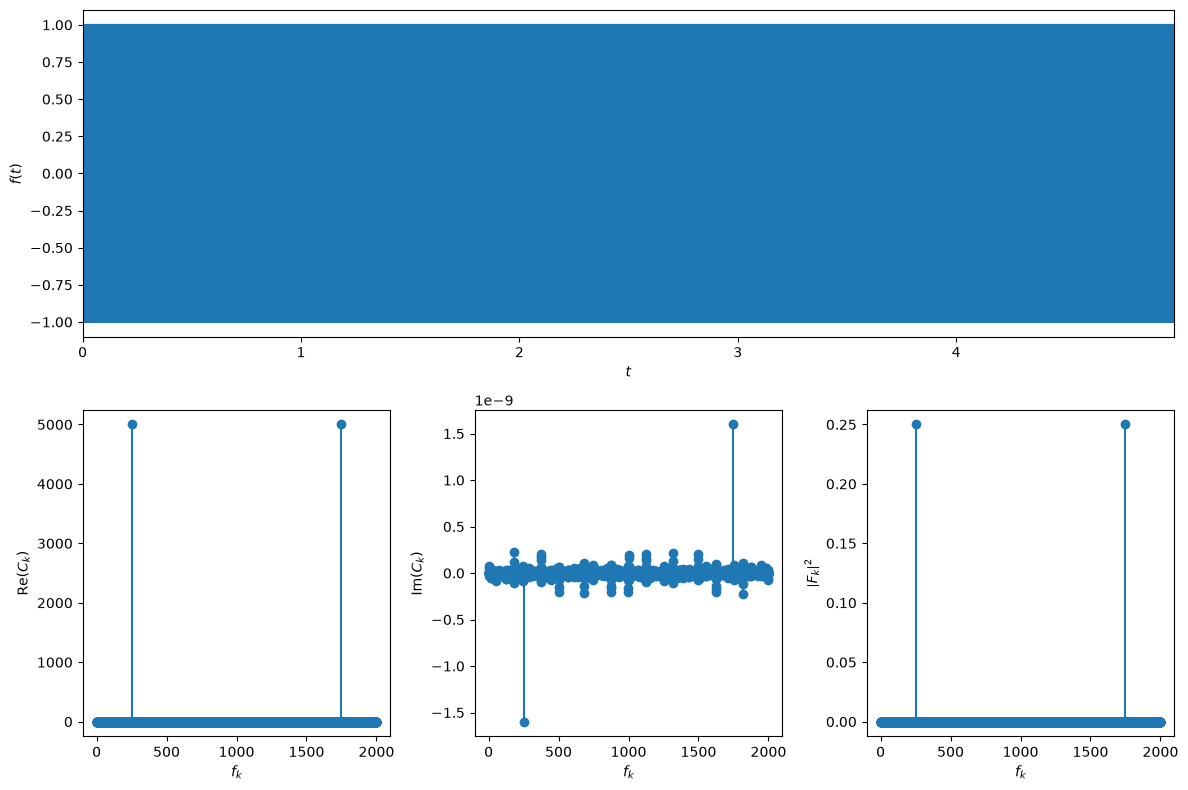

In [5]:
import numpy as np
from numpy.fft import fft
from matplotlib.pyplot import subplot_mosaic

f = 250

signal = lambda t : np.cos(2*np.pi*f*t)

sampling_start, sampling_end = 0, 5
sample_number = 10_000
sampling_interval = np.linspace(sampling_start, sampling_end, sample_number, endpoint=False)
frequencies = np.arange(len(sampling_interval)) / (sampling_end - sampling_start)

coefficients = fft(signal(sampling_interval))

fig, axs = subplot_mosaic([["signal", "signal", "signal"], ["real", "imag", "power"]], figsize=(12,8))

axs["signal"].plot(sampling_interval, signal(sampling_interval), ls="solid")

axs["signal"].set_xlim(left=np.min(sampling_interval), right=np.max(sampling_interval))

axs["signal"].set_xlabel(r"$t$")
axs["signal"].set_ylabel(r"$f(t)$")

axs["real"].stem(frequencies, np.real(coefficients), basefmt=" ")

axs["real"].set_ylabel(r"Re$(C_k)$")

axs["imag"].stem(frequencies, np.imag(coefficients), basefmt=" ")

axs["imag"].set_ylabel(r"Im$(C_k)$")

power_spectrum = np.abs(coefficients/len(sampling_interval))**2
axs["power"].stem(frequencies, power_spectrum, basefmt=" ")

axs["power"].set_ylabel(r"$\left\vert F_k \right\vert^2$")

for ax in (axs["real"], axs["imag"], axs["power"]):
    ax.set_xlabel(r"$f_k$")

fig.tight_layout()

rounded_spectrum = np.round(power_spectrum, 2)
peaks_freqs = np.nonzero(rounded_spectrum)
peaks_vals = power_spectrum[peaks_freqs]

print(f"Signal frequency: f = {f} Hz.")
print("After Fourier transform:")
for peak_freq, peak_val in zip(peaks_freqs[0], peaks_vals):
    print(f"Frequency peak at {frequencies[peak_freq]} Hz with power {peak_val:.3f}.")


Fourier 2. Exercise 3: Coarse sampling.

Signal frequencies: f_1 = 10 and f_2 = 50 Hz.
After Fourier transform:
Frequency peak at 10.0 Hz with power 0.250.
Frequency peak at 50.0 Hz with power 1.000.
Frequency peak at 150.0 Hz with power 1.000.
Frequency peak at 190.0 Hz with power 0.250.


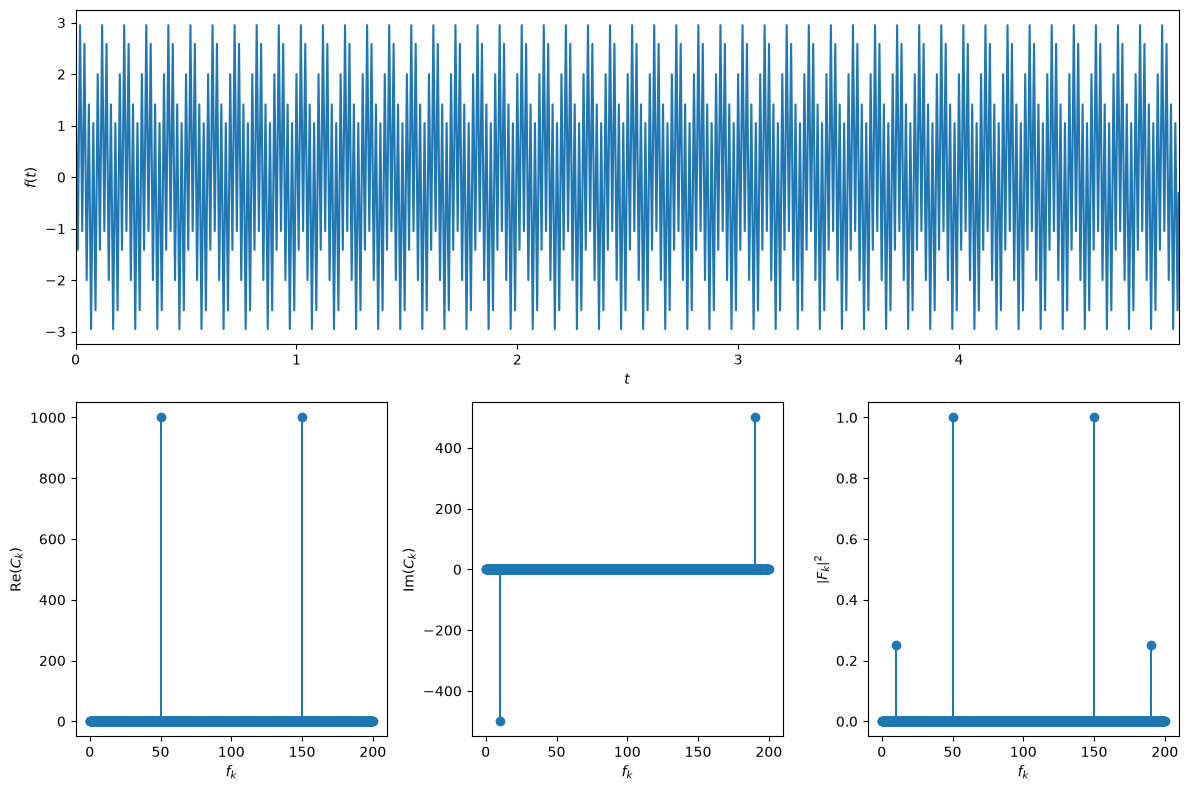

In [6]:
import numpy as np
from numpy.fft import fft
from matplotlib.pyplot import subplot_mosaic

f_1, f_2 = 10, 50

signal = lambda t : np.sin(2*np.pi*f_1*t) + 2*np.cos(2*np.pi*f_2*t)

sampling_start, sampling_end = 0, 5
sample_number = 1_000
sampling_interval = np.linspace(sampling_start, sampling_end, sample_number, endpoint=False)
frequencies = np.arange(len(sampling_interval)) / (sampling_end - sampling_start)

coefficients = fft(signal(sampling_interval))

fig, axs = subplot_mosaic([["signal", "signal", "signal"], ["real", "imag", "power"]], figsize=(12,8))

axs["signal"].plot(sampling_interval, signal(sampling_interval), ls="solid")

axs["signal"].set_xlim(left=np.min(sampling_interval), right=np.max(sampling_interval))

axs["signal"].set_xlabel(r"$t$")
axs["signal"].set_ylabel(r"$f(t)$")

axs["real"].stem(frequencies, np.real(coefficients), basefmt=" ")

axs["real"].set_ylabel(r"Re$(C_k)$")

axs["imag"].stem(frequencies, np.imag(coefficients), basefmt=" ")

axs["imag"].set_ylabel(r"Im$(C_k)$")

power_spectrum = np.abs(coefficients/len(sampling_interval))**2
axs["power"].stem(frequencies, power_spectrum, basefmt=" ")

axs["power"].set_ylabel(r"$\left\vert F_k \right\vert^2$")

for ax in (axs["real"], axs["imag"], axs["power"]):
    ax.set_xlabel(r"$f_k$")

fig.tight_layout()

rounded_spectrum = np.round(power_spectrum, 2)
peaks_freqs = np.nonzero(rounded_spectrum)
peaks_vals = power_spectrum[peaks_freqs]

print(f"Signal frequencies: f_1 = {f_1} and f_2 = {f_2} Hz.")
print("After Fourier transform:")
for peak_freq, peak_val in zip(peaks_freqs[0], peaks_vals):
    print(f"Frequency peak at {frequencies[peak_freq]} Hz with power {peak_val:.3f}.")
